# Milestone 2 - Task 6: Reward Levels vs. Campaign Success

This analysis investigates the relationship between the **number of reward tiers** offered by a Kickstarter campaign and whether the campaign was **successful or failed**. It uses the U.S.-filtered dataset produced by the earlier preprocessing tasks.


In [1]:
# NOTE: This notebook needs ../data/kickstarter_us_filtered.csv, created in the Task 4 notebook.
# The data/ folder is gitignored, so run Task 4 first if the file is missing.
import pandas as pd
import matplotlib.pyplot as plt

# Load the U.S.-filtered Kickstarter dataset
df = pd.read_csv("../data/kickstarter_us_filtered.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (38504, 17)


,project id,name,url,category,subcategory,location,status,goal,pledged,funded percentage,backers,funded date,levels,reward levels,updates,comments,duration
0,39409,WHILE THE TREES SLEEP,http://www.kickstarter.com/projects/emiliesaba...,Film & Video,Short Film,"Columbia, MO",successful,10500.0,11545.0,1.099524,66,"Fri, 19 Aug 2011 19:28:17 -0000",7,"$25,$50,$100,$250,$500,$1,000,$2,500",10,2,30.00
1,126581,Educational Online Trading Card Game,http://www.kickstarter.com/projects/972789543/...,Games,Board & Card Games,"Maplewood, NJ",failed,4000.0,20.0,0.005000,2,"Mon, 02 Aug 2010 03:59:00 -0000",5,"$1,$5,$10,$25,$50",6,0,47.18
2,237090,GETTING OVER - One son's search to finally kno...,http://www.kickstarter.com/projects/charnick/g...,Film & Video,Documentary,"Los Angeles, CA",successful,6000.0,6535.0,1.089167,100,"Sun, 08 Apr 2012 02:14:00 -0000",13,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",4,0,32.22
3,246101,The Launch of FlyeGrlRoyalty &quot;The New Nam...,http://www.kickstarter.com/projects/flyegrlroy...,Fashion,Fashion,"Novi, MI",failed,3500.0,0.0,0.000000,0,"Wed, 01 Jun 2011 15:25:39 -0000",6,"$10,$25,$50,$100,$150,$250",2,0,30.00
4,316217,Dinner Party - a short film about friendship.....,http://www.kickstarter.com/projects/249354515/...,Film & Video,Short Film,"Portland, OR",successful,3500.0,3582.0,1.023331,39,"Wed, 22 Jun 2011 13:33:00 -0000",7,"$5,$25,$50,$100,$250,$500,$1,000",8,0,21.43


In [2]:
# Inspect the reward-tier count and campaign status columns
print("Levels data type:", df["levels"].dtype)
print("Missing levels:", df["levels"].isna().sum())

print("\nCampaign status counts:")
print(df["status"].value_counts())

print("\nReward-tier count summary:")
print(df["levels"].describe())

Levels data type: int64
Missing levels: 0

Campaign status counts:
status
successful    21075
failed        17429
Name: count, dtype: int64

Reward-tier count summary:
count    38504.000000
mean         7.987352
std          4.216971
min          0.000000
25%          5.000000
50%          7.000000
75%         10.000000
max         80.000000
Name: levels, dtype: float64


In [3]:
# Compare reward-tier counts for successful and failed campaigns
levels_by_status = df.groupby("status")["levels"].agg(
    ["count", "mean", "median", "min", "max"]
)

levels_by_status

,count,mean,median,min,max
status,,,,,
failed,17429,7.310058,7.0,0,70
successful,21075,8.547473,8.0,0,80


In [4]:
# Calculate campaign count and success rate for each number of reward tiers
success_by_levels = (
    df.groupby("levels")["status"]
    .agg(
        campaign_count="count",
        success_rate=lambda x: (x == "successful").mean() * 100
    )
    .reset_index()
)

success_by_levels.head(15)

,levels,campaign_count,success_rate
0,0,41,39.024390
1,1,925,28.324324
2,2,787,34.815756
3,3,1714,40.840140
4,4,2729,47.489923
5,5,3718,49.435180
6,6,4597,53.447901
7,7,4933,55.909183
8,8,4718,56.591776
9,9,3798,57.030016


In [5]:
# Look at reward-tier counts above 14
success_by_levels[success_by_levels["levels"] > 14]

,levels,campaign_count,success_rate
15,15,492,68.902439
16,16,408,69.362745
17,17,263,75.285171
18,18,222,68.018018
19,19,166,72.289157
20,20,104,74.038462
21,21,82,65.853659
22,22,67,76.119403
23,23,74,64.864865
24,24,44,81.818182


Median: 7.0
Mode: 7

Percentiles:
0.25     5.0
0.50     7.0
0.75    10.0
0.90    13.0
0.95    15.0
0.99    22.0
Name: levels, dtype: float64

Campaigns with more than 20 tiers: 503 (1.31%)
Campaigns with 0-2 tiers: 1,753


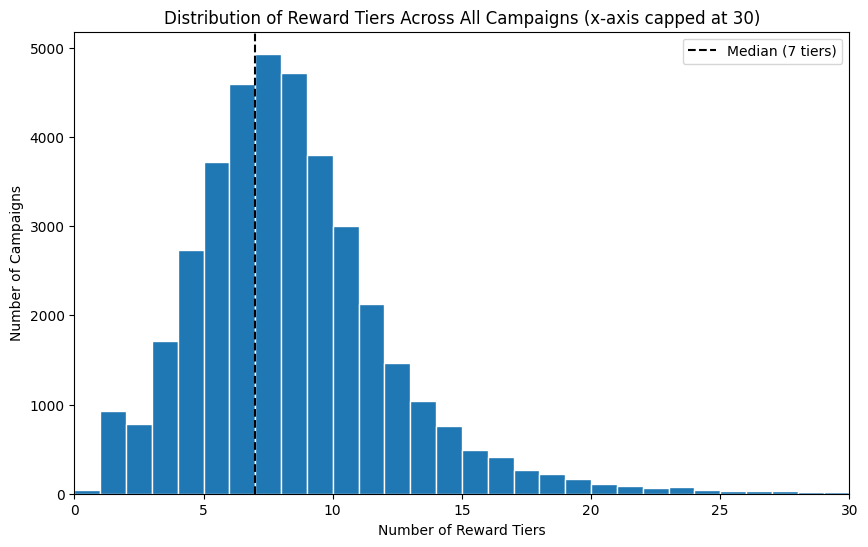

In [6]:
# Distribution of reward-tier counts across ALL campaigns
print("Median:", df["levels"].median())
print("Mode:", df["levels"].mode()[0])
print("\nPercentiles:")
print(df["levels"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

n_over_20 = (df["levels"] > 20).sum()
print(f"\nCampaigns with more than 20 tiers: {n_over_20:,} ({n_over_20 / len(df) * 100:.2f}%)")
print(f"Campaigns with 0-2 tiers: {(df['levels'] <= 2).sum():,}")

plt.figure(figsize=(10, 6))
plt.hist(df["levels"], bins=range(0, 32), edgecolor="white")
plt.axvline(df["levels"].median(), linestyle="--", color="black",
            label=f"Median ({df['levels'].median():.0f} tiers)")
plt.title("Distribution of Reward Tiers Across All Campaigns (x-axis capped at 30)")
plt.xlabel("Number of Reward Tiers")
plt.ylabel("Number of Campaigns")
plt.xlim(0, 30)
plt.legend()
plt.show()

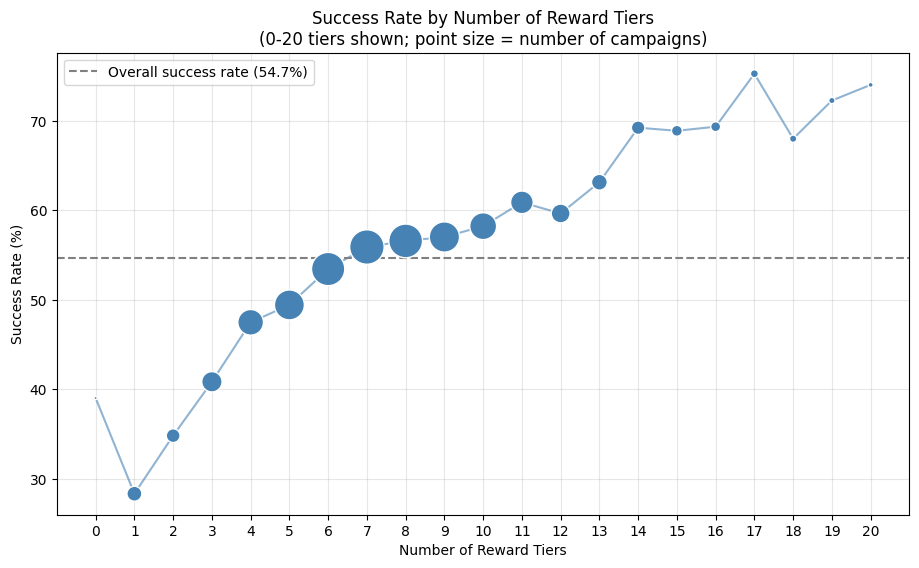

In [7]:
# Success rate by number of reward tiers (0-20 shown; point size = number of campaigns)
overall_success_rate = (df["status"] == "successful").mean() * 100
common_levels = success_by_levels[success_by_levels["levels"] <= 20]

plt.figure(figsize=(11, 6))
plt.plot(common_levels["levels"], common_levels["success_rate"], color="steelblue", alpha=0.6)
plt.scatter(
    common_levels["levels"],
    common_levels["success_rate"],
    s=common_levels["campaign_count"] / 8,
    color="steelblue",
    edgecolor="white",
    zorder=3,
)
plt.axhline(overall_success_rate, linestyle="--", color="gray",
            label=f"Overall success rate ({overall_success_rate:.1f}%)")
plt.title("Success Rate by Number of Reward Tiers\n(0-20 tiers shown; point size = number of campaigns)")
plt.xlabel("Number of Reward Tiers")
plt.ylabel("Success Rate (%)")
plt.xticks(range(0, 21))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

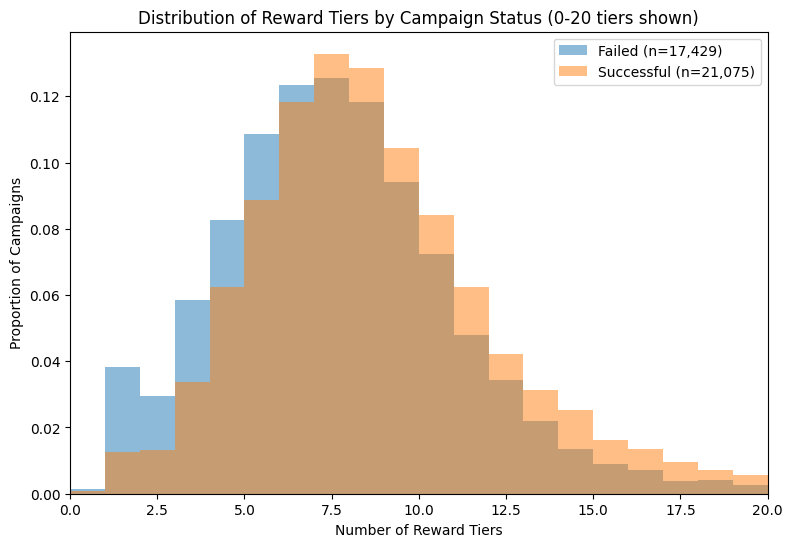

In [8]:
# Compare distributions as proportions (successful and failed groups differ in size)
plt.figure(figsize=(9, 6))

for status, label in [("failed", "Failed"), ("successful", "Successful")]:
    plt.hist(
        df[df["status"] == status]["levels"],
        bins=range(0, 22),
        density=True,
        alpha=0.5,
        label=f"{label} (n={(df['status'] == status).sum():,})",
    )

plt.title("Distribution of Reward Tiers by Campaign Status (0-20 tiers shown)")
plt.xlabel("Number of Reward Tiers")
plt.ylabel("Proportion of Campaigns")
plt.xlim(0, 20)
plt.legend()
plt.show()

            campaigns  success_rate
tier_group                         
0-2              1753          31.5
3-5              8161          47.0
6-10            21044          56.1
11-20            7043          64.1
21+               503          74.4


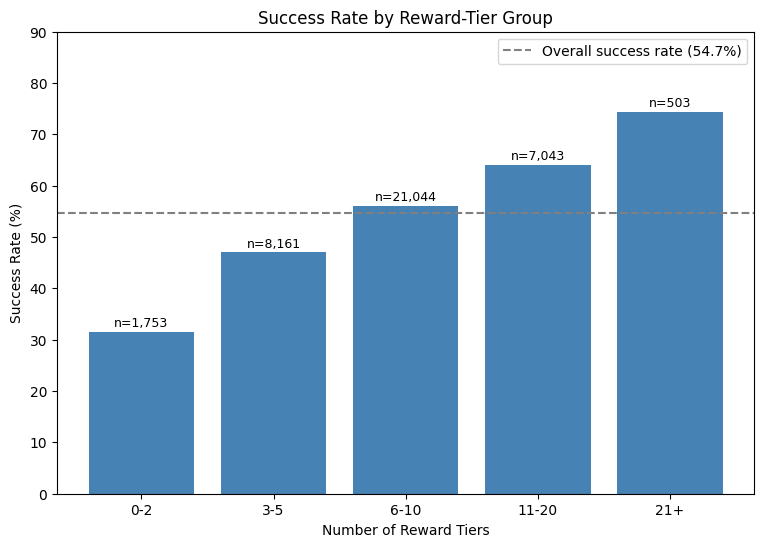

In [9]:
# Group tier counts into bins for a clearer, less noisy comparison
df["tier_group"] = pd.cut(
    df["levels"],
    bins=[-1, 2, 5, 10, 20, float("inf")],
    labels=["0-2", "3-5", "6-10", "11-20", "21+"],
)
df["success"] = (df["status"] == "successful").astype(int)

tier_group_summary = (
    df.groupby("tier_group", observed=True)["success"]
    .agg(campaigns="size", success_rate="mean")
)
tier_group_summary["success_rate"] = (tier_group_summary["success_rate"] * 100).round(1)
print(tier_group_summary)

plt.figure(figsize=(9, 6))
bars = plt.bar(tier_group_summary.index.astype(str), tier_group_summary["success_rate"],
               color="steelblue")
plt.axhline(overall_success_rate, linestyle="--", color="gray",
            label=f"Overall success rate ({overall_success_rate:.1f}%)")

for bar, n in zip(bars, tier_group_summary["campaigns"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"n={n:,}", ha="center", fontsize=9)

plt.title("Success Rate by Reward-Tier Group")
plt.xlabel("Number of Reward Tiers")
plt.ylabel("Success Rate (%)")
plt.ylim(0, 90)
plt.legend()
plt.show()

In [10]:
# Convert campaign status to a numeric success indicator
df["success"] = (df["status"] == "successful").astype(int)

# Calculate correlation between reward-tier count and campaign success
correlation = df["levels"].corr(df["success"])

print("Correlation between reward-tier count and campaign success:")
print(round(correlation, 3))


Correlation between reward-tier count and campaign success:
0.146


## Key Findings

- Reward-tier counts were available for all **38,504 campaigns**. The average campaign had about **7.99 reward tiers**, and the median was **7 tiers**.
- Most campaigns used a moderate number of reward tiers. **75% of campaigns had 10 or fewer tiers**, while only **503 campaigns (1.31%)** had more than 20 tiers.
- Successful campaigns had more reward tiers on average than failed campaigns. Successful campaigns averaged about **8.55 tiers**, compared with **7.31 tiers** for failed campaigns. The median was **8 tiers** for successful campaigns and **7 tiers** for failed campaigns.
- Success rates generally increased as the number of reward tiers increased. For example, campaigns with **1 reward tier** had a success rate of about **28%**, while campaigns with **10 reward tiers** had a success rate of about **58%**.
- Grouping campaigns into broader tier ranges showed the same overall pattern while reducing noise from rare high-tier counts. The grouped success rates increased from about **31.5% for 0–2 tiers** to **47.0% for 3–5 tiers**, **56.1% for 6–10 tiers**, **64.1% for 11–20 tiers**, and **74.4% for 21+ tiers**.
- Very high reward-tier counts were uncommon, so success rates for those values should be interpreted carefully because they are based on much smaller sample sizes.
- The correlation between reward-tier count and campaign success was **0.146**, showing a **weak positive relationship**. This means campaigns with more reward tiers tended to have higher success rates in this dataset, but reward-tier count alone is not a strong predictor of success.

Overall, reward-tier count may be a useful feature for future machine learning models and campaign recommendations, but it should be considered together with other campaign characteristics. These results show an **association**, not evidence that adding reward tiers directly causes a campaign to succeed.
